Johannes Husevåg Standal og Rozalia Ciupka

# CA2 - Supervised machine learning classification pipeline - applied to pumpkin seed variety classification


### Important information

- Do __not__ use scikit-learn (`sklearn`) or any other high-level machine learning library for this CA
- Explain your code and reasoning in markdown cells or code comments
- Label all graphs and charts if applicable
- If you use code from the internet, make sure to reference it and explain it in your own words
- If you use additional function arguments, make sure to explain them in your own words
- Use the classes `Perceptron`, `Adaline` and `Logistic Regression` from the library `mlxtend` as classifiers (`from mlxtend.classifier import Perceptron, Adaline, LogisticRegression`). _Always_ use the argument `minibatches=1` when instantiating an `Adaline` or `LogisticRegression` object. This makes the model use the gradient descent algorithm for training. Always use the `random_seed=42` argument when instantiating the classifiers. This will make your results reproducible.
- You can use any plotting library you want (e.g. `matplotlib`, `seaborn`, `plotly`, etc.)
- Use explanatory variable names (e.g. `X_train` and `X_train_scaled` for the training data before and after scaling, respectively)
- The dataset is provided in the file `pumpkin_dataset.csv` 

### About the dataset

Each row describes one pumpkin seed, measured automatically from a photograph. The four features are geometric properties of the seed:

- `Compactness`: how close the seed's shape is to a circle (ratio; 1 = perfectly round, smaller = more elongated)
- `Major_Axis_Length`: length of the longest line that fits inside the seed (pixels)
- `Extent`: ratio of the seed area to the area of its bounding box
- `Area`: number of pixels inside the seed

The target `class` is the seed variety: `0` = Çerçevelik, `1` = Ürgüp Sivrisi.

The data comes from Koklu, Sarigil & Ozbek (2021), *The use of machine learning methods in classification of pumpkin seeds (Cucurbita pepo L.)*, Genetic Resources and Crop Evolution 68(7), 2713–2726. https://doi.org/10.1007/s10722-021-01226-0

### Additional clues

- Use the `pandas` library for initial data inspection and preprocessing
- Before training the classifiers, convert the data to raw `numpy` arrays
- For Part IV, you are aiming to create a plot that looks similar to this:
<img src="./example_output_pumpkin.png" width="700">

### Additional information

- Feel free to create additional code or markdown cells if you think it will help you explain your reasoning or structure your code (you don't have to).


## Part I: Data loading and data exploration


### Import necessary libraries/modules:


In [132]:
# Insert your code below
# ======================

import pandas as pd
import numpy as np 
from mlxtend.classifier import Perceptron, Adaline, LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns
import time

### Loading and exploring data

1. Load the dataset `pumpkin_dataset.csv` with `pandas`.
2. Check for missing data, report your findings, and remove samples with missing data if any are present.
3. Display the raw data with appropriate plots/outputs and inspect it. Describe the distributions of:
   - feature `"Compactness"`
   - feature `"Area"`
   - the target variable `"class"`
4. Will it be beneficial to scale the data? Why or why not?
5. Is the data linearly separable using any pairwise combination of features? Based on your observations, can we expect an accuracy close to 100% from a linear classifier?


Compactness          0
Major_Axis_Length    0
Extent               0
Area                 0
class                0
dtype: int64
Compactness          0
Major_Axis_Length    0
Extent               0
Area                 0
class                0
dtype: int64


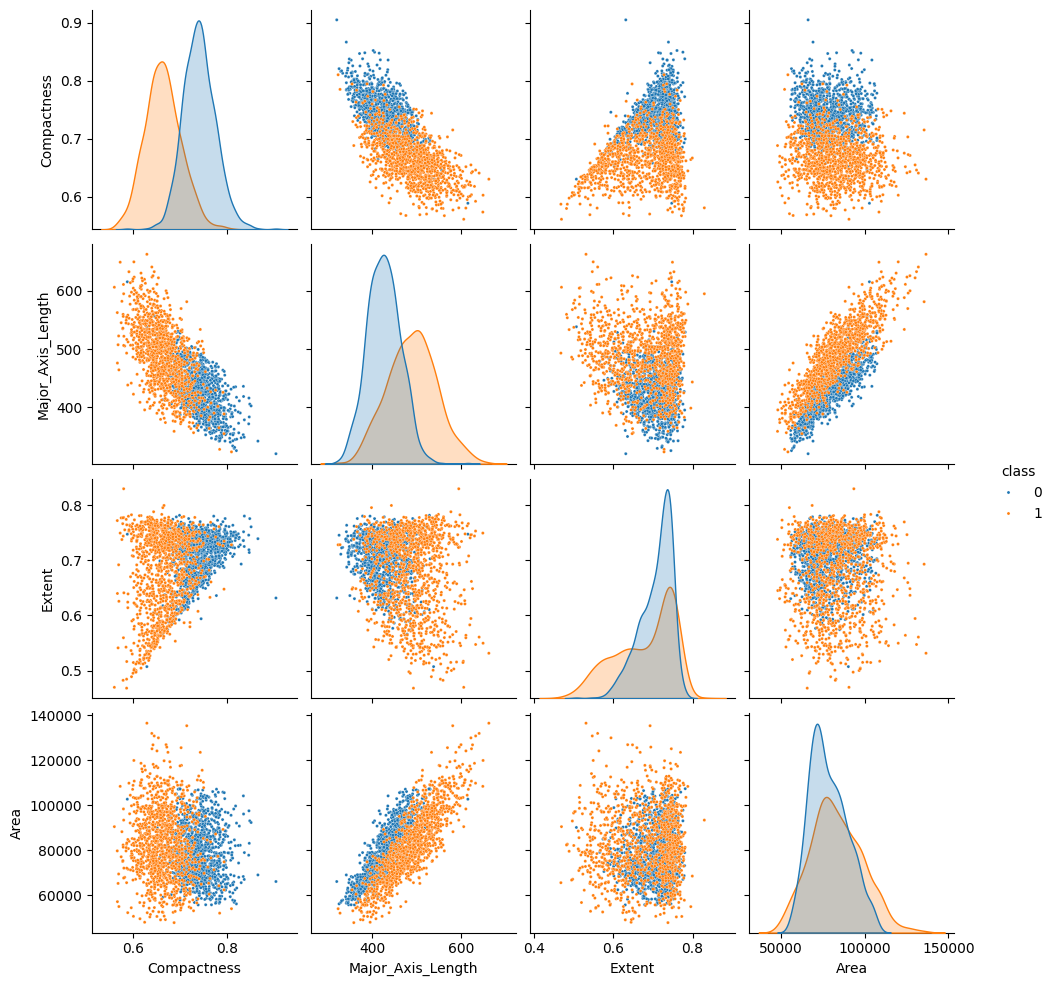

In [133]:
# Insert your code below
# ======================
df = pd.read_csv("pumpkin_dataset.csv")

# 2 Check for missing data
print(df.isna().sum())
print(df.isnull().sum())

# 3 distributions
# Parameters from https://seaborn.pydata.org/generated/seaborn.pairplot.html
sns.pairplot(df,  hue='class', plot_kws={'s':5})

2. There is no missing data

3. I am not sure what this means? Do they want me to say that there is a huge difference between Area and Compactness in scale?

4. It would be beneficial to scale the data because of the difference in numerical size between for example compactness and area. 

5. Interperting the plot there are some candidates for a linearly seperable. Some feature pairs such as (Major_Axis_Length, Area), (Major_Axis_Length, Compactness) and (Compactness, Area), can be in some way linearly seperated. The most promising candidate 
appears to be (Major_Axis_Length, Area) wich could circle around 100% accuracy. 

## Part II: Train/Test Split

Divide your dataset into training and testing subsets. Follow these steps to create the split:

1. **Divide the dataset into two data sets, each containing samples of only one class:**
   - Create a DataFrame `df_0` containing all samples with `"class"` equal to `0`.
   - Create a DataFrame `df_1` containing all samples with `"class"` equal to `1`.

2. **Split into training and test sets by randomly sampling entries from the data frames:**
   - Create a DataFrame `df_0_train` by sampling `75%` of the entries from `df_0` (use the `sample` method with `random_state=42`).
   - Create a DataFrame `df_1_train` using the same approach with `df_1`.
   - Create a DataFrame `df_0_test` containing the remaining entries of `df_0` (use `df_0.drop(df_0_train.index)`).
   - Create a DataFrame `df_1_test` using the same approach with `df_1`.

3. **Merge the datasets split by classes back together:**
   - Create a DataFrame `df_train` containing all entries from `df_0_train` and `df_1_train` (use the `concat` method).
   - Create a DataFrame `df_test` containing all entries from the two test sets.

4. **Create the following data frames from these splits:**
   - `X_train`: contains all columns of `df_train` except for the target feature `"class"`
   - `X_test`: contains all columns of `df_test` except for the target feature `"class"`
   - `y_train`: contains only the target feature `"class"` for all samples in the training set
   - `y_test`: contains only the target feature `"class"` for all samples in the test set

5. **Check that your sets have the expected sizes/shape by printing the number of rows and columns (`shape`) of the data sets.**
   - (Sanity check: there should be **4 features**, and the training set should contain roughly **75%** of the total samples, with the test set containing the remaining **25%**.)

6. **Explain the purpose of this slightly complicated procedure.**
   - Why did we first split into the two classes?
   
   We split the classes so that the training and test set can have the same proportion between the two classes. If we just split the dataframe we could get a result like this.

   Train (total 75%) - Class_0 = 90%, Class_1 = 10%
   Train (total 25%) - Class_0 = 20%, Class_1 = 80%
   
   This is very bad for the accuracy of the model. It is like studying math for 100 hours only to take a litterature exam. 
   
   - Why did we then split into a training and a testing set?

   If used the entire dataset we run the risk of overfitting our model. Essentially making the model memorise all of the answers.
   By splitting the data we can test our model accuracy on data it has never seen before, giving us an estimate on how well this model would perform in a real enviroment.

7. **What is the share (in percent) of samples with class `0` in the test set, training set, and in the initial data set?**




In [134]:
# Insert your code below
# ======================
df_0 = df[df['class'] == 0]
df_1 = df[df['class'] == 1]

# Use 75% of the dataset for training
df_0_train = df_0.sample(frac=3/4, random_state=42)
df_1_train = df_1.sample(frac=3/4, random_state=42)

# Use 25% of the dataset for training
df_0_test = df_0.drop(df_0_train.index)
df_1_test = df_1.drop(df_1_train.index)

# Merge the training sets. This ensures that both the training and test set contain both seed classifications
df_train = pd.concat([df_0_train, df_1_train])
df_test = pd.concat ([df_0_test,  df_1_test ])

# Create dataframes
x_train = df_train.drop(columns = ["class"])
x_test = df_test.drop(columns = ["class"])

y_train = pd.DataFrame(df_train["class"])
y_test = pd.DataFrame(df_test["class"])

# 5. Sanity check
# Check dataframes. Output shows no loss
print("Is the training and test dataframe distributed 25 / 75 ?")
print("full: ", df.shape)
print("train: ",df_train.shape)
print("test: ",df_test.shape)

# 6. Check the split dataframes. Output shows no loss, and the correct number of columns and rows
print("\n Has the split dataframes lost any data, and has the correct number of columns and rows?")
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

# 7. Class_0 distribution in the datasets
print("\n Distribution of class 0 in the datasets")
print(f"Full set: {(df['class'] == 0).mean() * 100}%")
print(f"Training set: {(df_train['class'] == 0).mean() * 100}%")
print(f"Test set: {(df_test['class'] == 0).mean() * 100}%")

Is the training and test dataframe distributed 25 / 75 ?
full:  (2500, 5)
train:  (1875, 5)
test:  (625, 5)

 Has the split dataframes lost any data, and has the correct number of columns and rows?
(1875, 4)
(625, 4)
(1875, 1)
(625, 1)

 Distribution of class 0 in the datasets
Full set: 52.0%
Training set: 52.0%
Test set: 52.0%


### Convert data to numpy arrays and shuffle the training data

Many machine learning models (including those you will use later in this assignment) do not accept `pandas` DataFrames as input. Instead, they require the data to be provided as raw `numpy` arrays.  
In this step, convert the DataFrames `X_train`, `X_test`, `y_train`, and `y_test` into the corresponding numpy arrays with the same variable names.

In addition, shuffle the training data. This is necessary because the training set is currently ordered by class (all samples of class 0 followed by all samples of class 1).  
In Part IV, the classifiers will be trained using the **first _n_ samples** of the training set. If the data were not shuffled, the models would initially be trained only on samples from a single class, which would lead to biased learning and unreliable performance.

Nothing to be done here, just execute the cell.


In [135]:
# convert to numpy arrays
X_train = x_train.to_numpy()
X_test = x_test.to_numpy()
y_train = y_train.to_numpy()
y_test = y_test.to_numpy()

# shuffle training data
np.random.seed(42) # for reproducibility
shuffle_index = np.random.permutation(len(X_train)) # generate random indices
X_train, y_train = X_train[shuffle_index], y_train[shuffle_index] # shuffle data by applying reordering with the random indices

## Part III: Scaling the data

1. Standardize the training _and_ test data so that each feature has a mean of 0 and a standard deviation of 1.
2. Check that the scaling was successful
   - by printing the mean and standard deviation of each feature in the scaled training set
   - by putting the scaled training set into a DataFrame and making a violin plot of the data

__Hint:__ use the `axis` argument to calculate mean and standard deviation column-wise.

__Important:__ Avoid data leakage!  
Compute the mean and standard deviation only on the training data, and then apply the same transformation to both the training and test sets.

__More hints:__

1. For each column, subtract the training mean $(\mu_{\text{train}})$ from each value in that column  
2. Divide the result by the training standard deviation $(\sigma_{\text{train}})$

Mathematically, this transformation for each column is:

$$ X_{\text{scaled}} = \frac{X - \mu_{\text{train}}}{\sigma_{\text{train}}}$$

where:
- $X_{\text{scaled}}$ are the transformed column values (a column vector)  
- $X$ is the original column  
- $\mu_{\text{train}}$ is the mean of the column computed on the training set  
- $\sigma_{\text{train}}$ is the standard deviation of the column computed on the training set  



Check if all features have STD = 1 and MEAN = 0
std:  [1.03376965 0.99961509 1.05477408 0.97850552] mean:  [-0.0386408   0.05782999 -0.06558693  0.04276017]
std:  [1. 1. 1. 1.] mean:  [ 1.63539589e-14 -8.46582064e-16 -1.05821130e-14  1.49332398e-16]


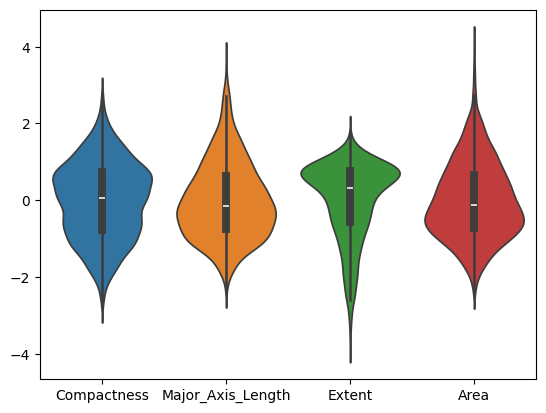

In [136]:
# Insert your code below
# ======================
train_Std = np.std(X_train, axis=0 )
train_Mean = np.mean(X_train, axis=0)

X_train_scaled = (X_train - train_Mean) / train_Std
X_test_scaled  = (X_test  - train_Mean) / train_Std

df_train_scaled = pd.DataFrame(X_train_scaled, columns=['Compactness', 'Major_Axis_Length', 'Extent', 'Area'])
sns.violinplot(df_train_scaled)

print("\nCheck if all features have STD = 1 and MEAN = 0")
print("std: ", X_test_scaled.std(axis=0),  "mean: ", X_test_scaled.mean(axis=0))
print("std: ", X_train_scaled.std(axis=0), "mean: ", X_train_scaled.mean(axis=0))

## Part IV: Training and evaluation with different dataset sizes and training times

Often, a larger dataset size will yield better model performance. (As we will learn later, this usually prevents overfitting and increases the generalization capability of the trained model.)
However, collecting data is usually rather expensive.

In this part of the exercise, you will investigate

- how the model performance changes with varying dataset size
- how the model performance changes with varying numbers of epochs/iterations of the optimizer/solver (increasing training time).

For this task (Part IV), use the `Adaline`, `Perceptron`, and `LogisticRegression` classifiers from the `mlxtend` library. All use the gradient descent (GD) algorithm for training.

__Important__: Use a learning rate of `1e-5` (`0.00001`) for all classifiers, and use the argument `minibatches=1` when initializing the `Adaline` and `LogisticRegression` classifiers (this will make sure they use GD). For all three classifiers, pass `random_seed=42` when initializing the classifier to ensure reproducibility of the results.

### Model training

Train the models using progressively larger subsets of your dataset, specifically: first 50 rows, first 100 rows, first 150 rows, ..., first 650 rows, first 700 rows (in total $14$ different variants).

For each number of rows train the model with progressively larger number of epochs: 2, 7, 12, 17, ..., 87, 92, 97 (in total $20$ different model variants).

This will result in $14 \times 20 = 280$ models obtained from the different combinations of subsets and number of epochs. An output of the training process could look like this:

```
Model (1) Train a model with first 50 rows of data for 2 epochs
Model (2) Train a model with first 50 rows of data for 7 epochs
Model (3) Train a model with first 50 rows of data for 12 epochs
...
Model (21) Train a model with first 100 rows of data for 2 epochs
Model (22) Train a model with first 100 rows of data for 7 epochs
...
Model (279) Train a model with first 700 rows of data for 92 epochs
Model (280) Train a model with first 700 rows of data for 97 epochs
```

### Model evaluation

For each of the $280$ models, calculate the __accuracy on the test set__ (do __not__ use the score method but compute accuracy yourself).
Store the results in the provided 2D numpy array (it has $14$ rows and $20$ columns).
The rows of the array correspond to the different dataset sizes, and the columns correspond to the different numbers of epochs.

### Tasks
1. Train the $280$ Adaline classifiers as mentioned above and calculate the accuracy for each of the $280$ variants.
2. Generalize your code so that it is doing the same procedure for all three classifiers: `Perceptron`, `Adaline`, and `LogisticRegression` after each other. Store the result for all classifiers. You can for example use an array of shape $3\times14\times20$ to store the accuracies of the three classifiers.

Note that executing the cells will take some time (but on most systems it should not be more than 5 minutes).


In [137]:
# Train and evaluate all model variants
# Insert your code below
# ======================
n_rows = [i for i in range(50, 701, 50)]
n_epochs = [i for i in range(2, 98, 5)]

classifiers = [Adaline, Perceptron, LogisticRegression]
learning_rate = 1e-5
seed = 42

accuracies = np.zeros((3, len(n_rows), len(n_epochs))) 

model = 1

X_train_scaled = np.asarray(X_train_scaled) # converts the pandas dataframe to np.array since .to_numpy does not work 
X_test_scaled = np.asarray(X_test_scaled)

y_train = y_train.flatten() # makes a 1D array out of the 2D array it was before
y_test = y_test.flatten()

for clf_index, clf_class in enumerate(classifiers):
    clf_name = clf_class.__name__ # Retrieves the name of the model for better output of the training process

    startTime = time.time()
    for row_index, num_rows in enumerate(n_rows):
        X_subset = X_train_scaled[:num_rows] # Retrieves the first n rows for the training 
        y_subset = np.array(y_train[:num_rows])

        for epoch_index, num_epochs in enumerate(n_epochs):
            print(f"Model ({model}) Train a {clf_name} model with first {num_rows} rows of data for {num_epochs} epochs")
            model += 1

            if clf_class == Perceptron: # Perceptron does'nt take the minibatches argument
                clf = clf_class(epochs=num_epochs, eta=learning_rate, random_seed=seed)
            else:
                clf = clf_class(epochs=num_epochs, eta=learning_rate, minibatches=1, random_seed=seed)

            clf.fit(X_subset, y_subset) # Training the model

            y_pred = clf.predict(X_test_scaled) # Predicts the classes for the test set 

            accuracy = np.sum(y_test == y_pred) / len(y_test)

            accuracies[clf_index, row_index, epoch_index] = accuracy

    endTime = time.time()
    print(f"Finished training the {clf_name} model in {(endTime-startTime):.2f} seconds")



Model (1) Train a Adaline model with first 50 rows of data for 2 epochs
Model (2) Train a Adaline model with first 50 rows of data for 7 epochs
Model (3) Train a Adaline model with first 50 rows of data for 12 epochs
Model (4) Train a Adaline model with first 50 rows of data for 17 epochs
Model (5) Train a Adaline model with first 50 rows of data for 22 epochs
Model (6) Train a Adaline model with first 50 rows of data for 27 epochs
Model (7) Train a Adaline model with first 50 rows of data for 32 epochs
Model (8) Train a Adaline model with first 50 rows of data for 37 epochs
Model (9) Train a Adaline model with first 50 rows of data for 42 epochs
Model (10) Train a Adaline model with first 50 rows of data for 47 epochs
Model (11) Train a Adaline model with first 50 rows of data for 52 epochs
Model (12) Train a Adaline model with first 50 rows of data for 57 epochs
Model (13) Train a Adaline model with first 50 rows of data for 62 epochs
Model (14) Train a Adaline model with first 50 ro

### Performance visualization

Plot the performance measure for all classifiers (accuracy on the test set; use the result array from above) of all the $280$ variants for each classifier in a total of three heatmaps using, for example `seaborn` or `matplotlib` directly.

The color should represent the accuracy on the test set, and the x and y axes should represent the number of epochs and the dataset size, respectively.
Which one is x and which one is y is up to you to decide. Look in the example output at the top of the assignment for inspiration for how the plot could look like and how it could be labeled nicely. (But use the correct numbers corresponding to your dataset sizes and number of epochs.)


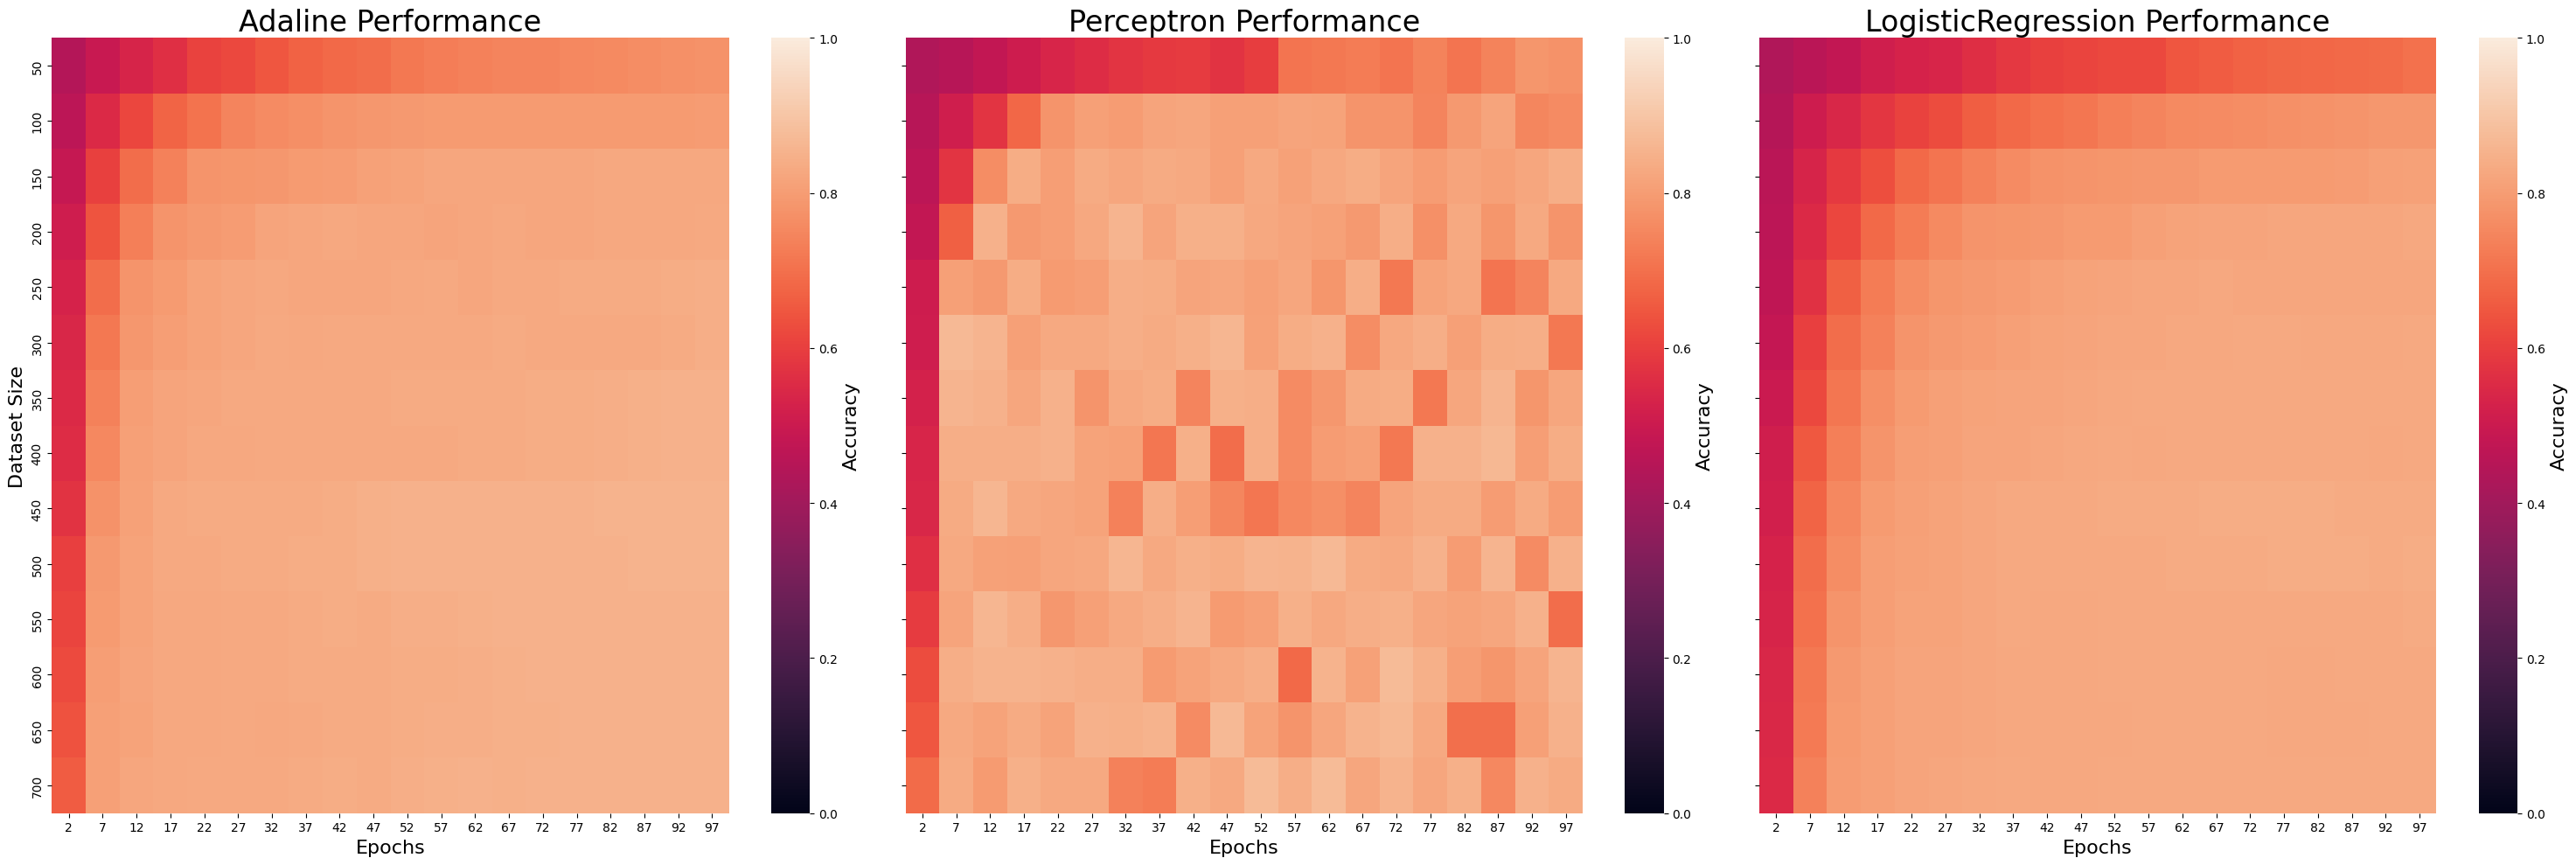

In [138]:
# Insert your code below
# ======================
fig, axes = plt.subplots(1, 3, sharey=True, figsize=(30, 10)) # Creates 3 subplots where they share one y-axis

clf_names = ['Adaline', 'Perceptron', 'LogisticRegression']

x_labels = n_epochs
y_labels = n_rows

for clf_index, name in enumerate(clf_names):
    data = accuracies[clf_index, :, :] # In previous code a 3D array was made, now we retrieve the 2D array out of it.

    plot = sns.heatmap(
        data,
        xticklabels=x_labels,
        yticklabels=y_labels,
        ax=axes[clf_index],
        vmin=0,
        vmax=1
    )

    axes[clf_index].set_title(f'{name} Performance', fontsize=24)
    axes[clf_index].set_xlabel('Epochs', fontsize=16)
    cbar = plot.collections[0].colorbar.set_label('Accuracy', fontsize=16) # creates the colorbar on the side of the heatmap

    if clf_index == 0:
        axes[clf_index].set_ylabel('Dataset Size', fontsize=16)

plt.tight_layout() # Adjust layout so nothing overlaps and there are no big gaps between the plots

# Part V: Some more plotting
For the following cell to execute you need to have the variables `X_train_scaled` and `y_train` (to train the model) as well as `X_test_scaled` and `y_test` (to plot the test samples).
Complete at least up until Part III. Executing the cell will plot something.

This dataset has 4 features, so the plot will be a 4×4 grid showing pairwise feature decision regions.


1. Add code comments explaining what the lines are doing
2. What is the purpose of the plot?

The plot offers a simple visual on how well our model and selected features work for predicting the class given any data. An ideal model should have a clear decision boundary that seperates the actual data with 100% accuracy. 

3. Describe all components of the subplot and then comment in general on the entire plot. What does it show? What does it not show?

The plot shows the prediction of a class from every pairwise combintation of features. The scaled data is represented as blue triangles and yellow circles. The background color represents our models prediction, and the black line is the models decision boundary. The entire plot shows us how well the decision boundary seperates our data. 

The plot does not show anything more than a two dimensional decison boundary. It assumes that all other features are fixed at 0, and is therefore not capable of visualizing the four dimensional hyperplane for all 4 features. The subplots are simply slices of the model, not the full model itself.   



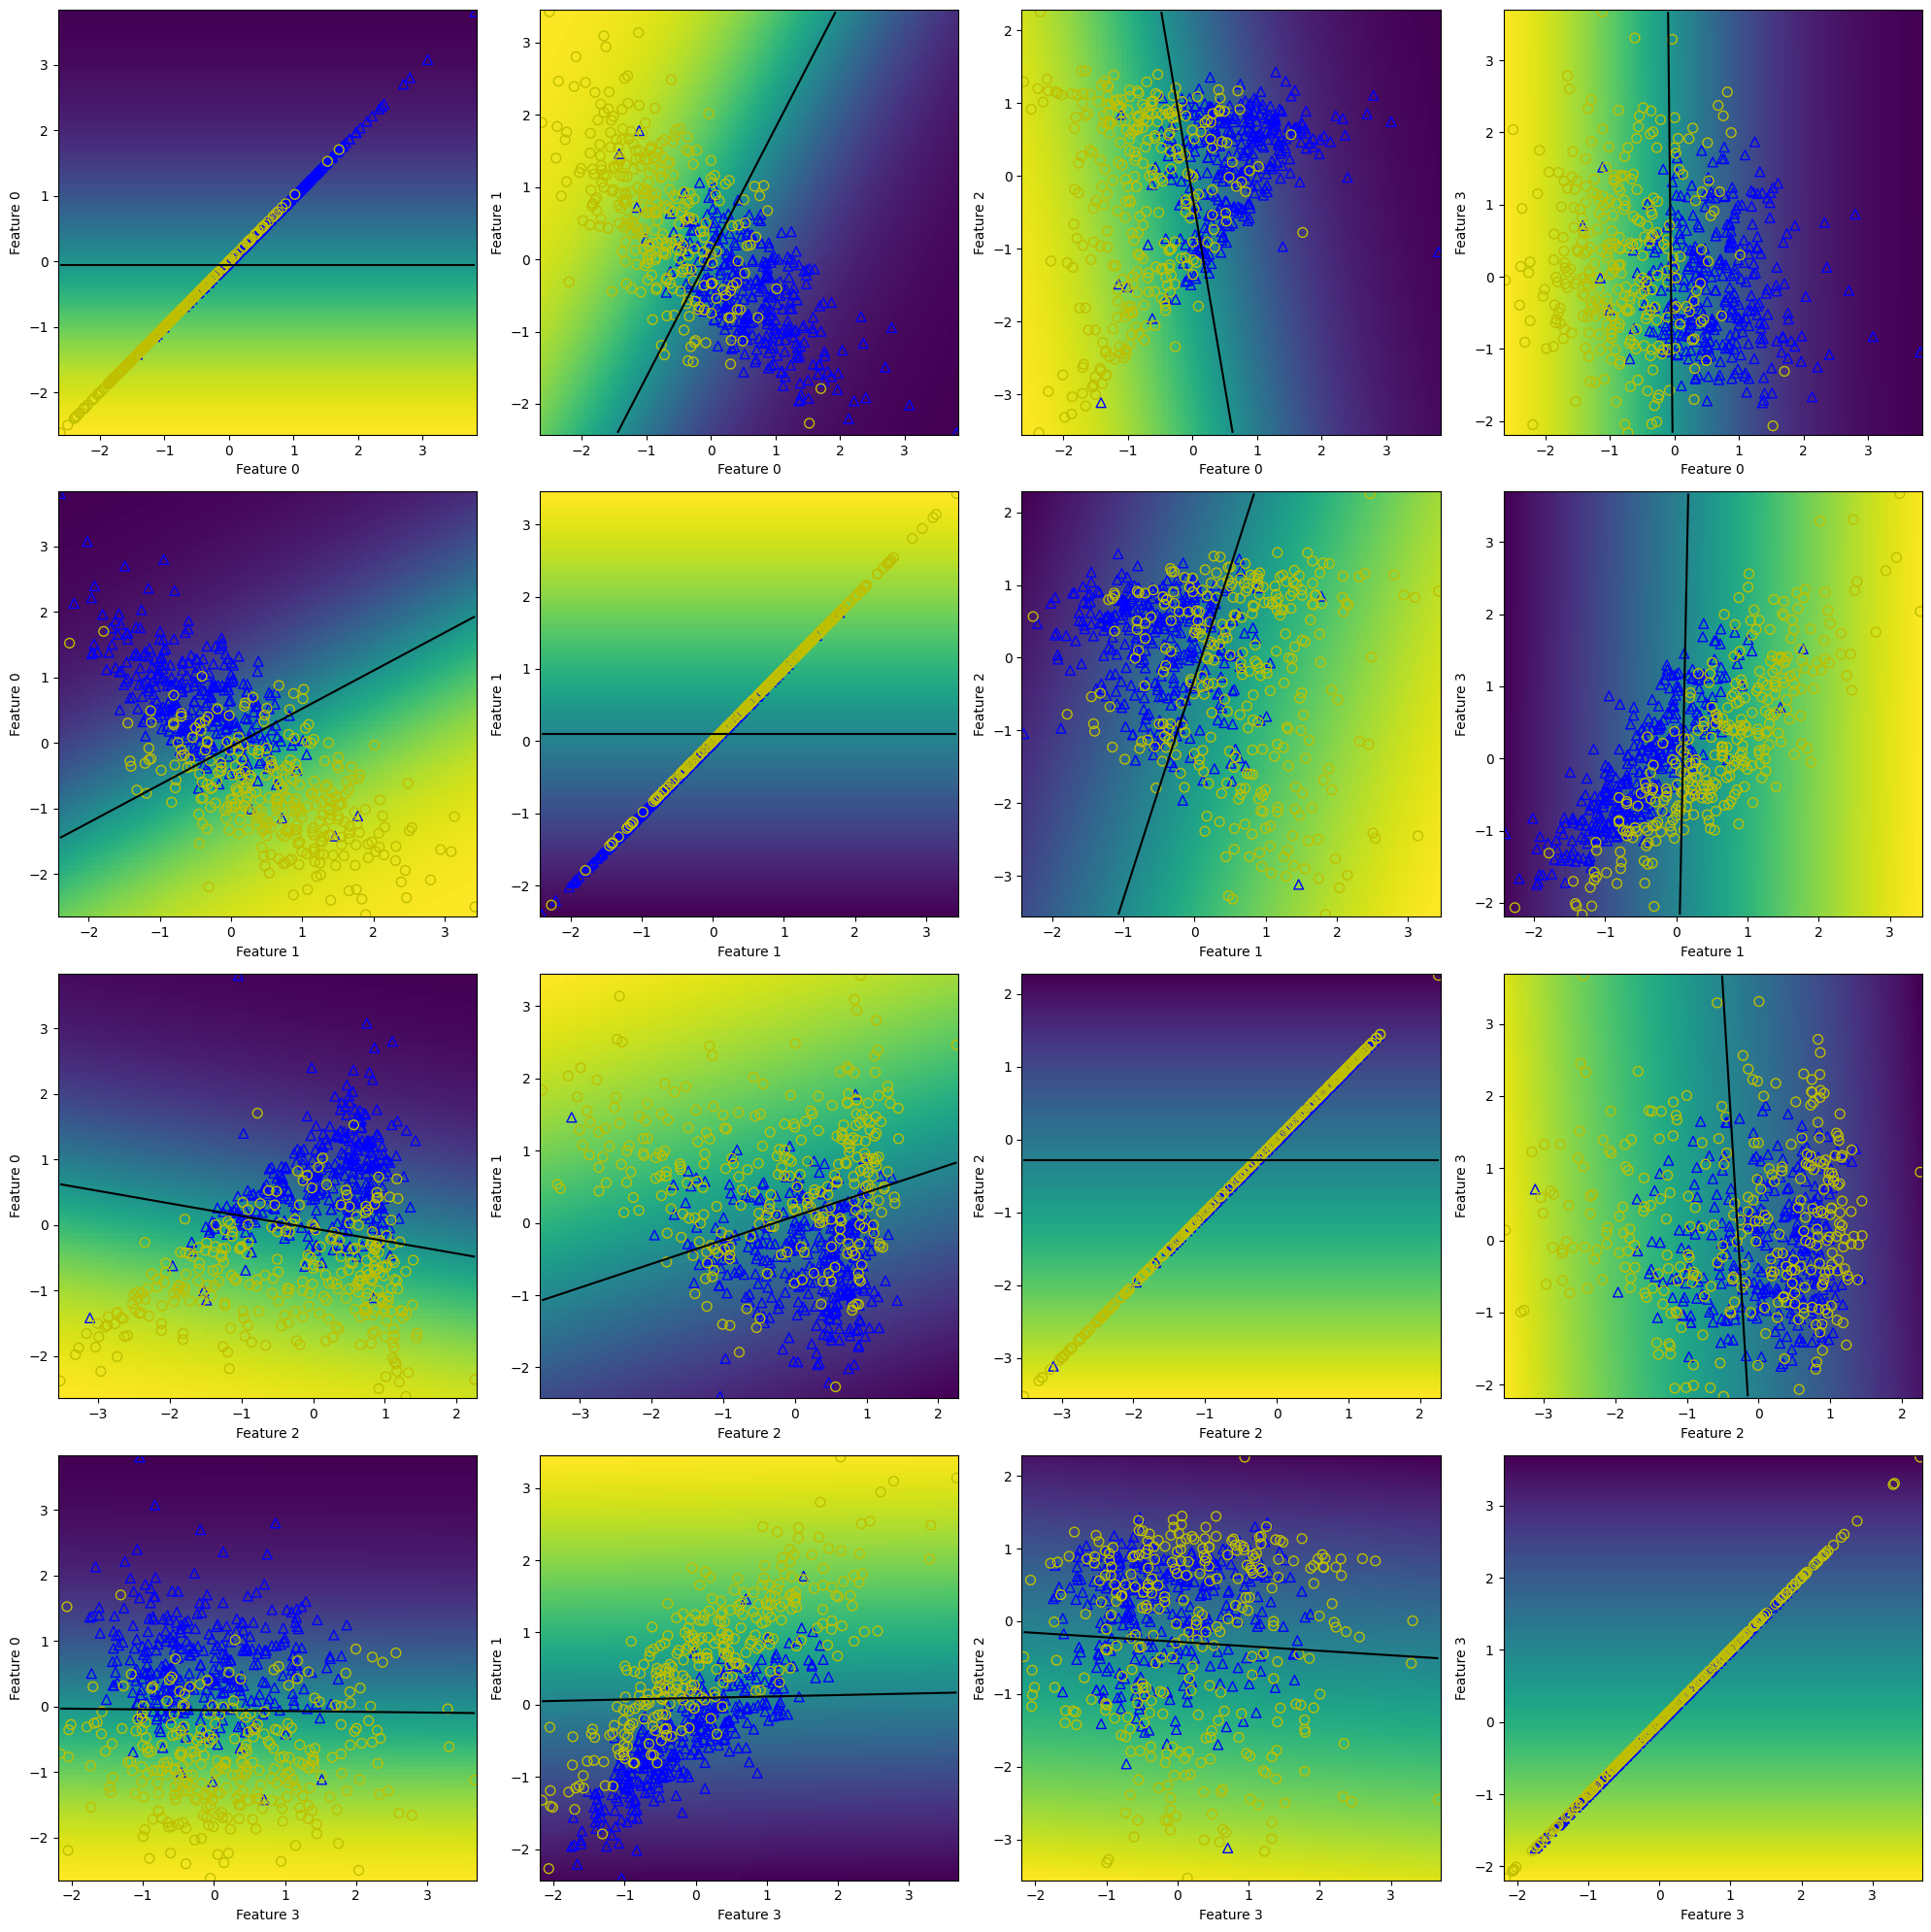

In [139]:
clf = LogisticRegression(eta=1e-5, epochs=300, minibatches=1, random_seed=42) # Sets up the classification model parameters 
clf.fit(X_train_scaled, y_train) # Trains the model on scaled data

n_features = X_test_scaled.shape[1] # Retrieves the number of columns in the scaled test subdataset

# Create a n_features x n_features (4x4) grid of plots with a scaled figure size
fig, axes = plt.subplots(n_features, n_features, figsize=(5*n_features, 5*n_features)) 

# Compute the minimum and maximum value for each feature in the dataset
mins = X_test_scaled.min(axis=0)
maxs = X_test_scaled.max(axis=0)

# Iterates over all pairs of features  
for i in range(n_features):
    for j in range(n_features):

        feature_1 = i # Feature set to the x-axis
        feature_2 = j # Feature set to the y-axis
        ax = axes[i, j] # Defines the axes for the subplot

        # Labels subplot axes with corresponding feature numbers
        ax.set_xlabel(f"Feature {feature_1}")
        ax.set_ylabel(f"Feature {feature_2}")

        # Create grid for the two selected features
        x0 = np.linspace(mins[feature_1], maxs[feature_1], 100)
        x1 = np.linspace(mins[feature_2], maxs[feature_2], 100)

        # Build a 2D coordinate grid based on the two arrays x0 and x1 
        X0, X1 = np.meshgrid(x0, x1)

        # Create full feature matrix with other features set to 0
        X_plot = np.zeros((X0.size, n_features))
        # Flattens the arrays to create a grid of 100x100 that gives 10 000 values 
        X_plot[:, feature_1] = X0.ravel() 
        X_plot[:, feature_2] = X1.ravel()

        # Predict probability of class 1
        y_pred = clf.predict_proba(X_plot)
        Z = y_pred.reshape(X0.shape)

        # Plot probability surface
        ax.pcolor(X0, X1, Z, shading="auto")

        # Plot decision boundary (p = 0.5)
        ax.contour(X0, X1, Z, levels=[0.5], colors="k")

        # Plot test samples
        ax.scatter(
            X_test_scaled[y_test == 0, feature_1],
            X_test_scaled[y_test == 0, feature_2],
            color="b", marker="^", s=50, facecolors="none"
        )

        ax.scatter(
            X_test_scaled[y_test == 1, feature_1],
            X_test_scaled[y_test == 1, feature_2],
            color="y", marker="o", s=50, facecolors="none"
        )

fig.tight_layout()
plt.show()

## Part VI: Additional discussion

### Part I:
1. What kind of plots did you use to visualize the raw data, and why did you choose these types of plots?

We used seaborns pairplotts to visualize the data, because it was easier than making subplots with matplotlib, and it could combine the histograms with scatterplotts in an "easy on the eye" way. 

### Part II:
1. What happens if we don't shuffle the training data before training the classifiers like in Part IV?

In that instance we risk that our model does not encounter the other classes (here class 1), which in turn could mean that the results could be biased and the performance could be unreliable.


2. How could you do the same train/test split (Point 1.-4.) using scikit-learn?

You could use scikits "train_test_split()" method to seperate the data into 4 arrays.
It takes in two dataframes for features, and result (in our case class), and parameters for "random_state" and "test_size". 

### Part IV:
All information is interpreted from the heatmaps from part 4

1. How does increasing the dataset size affect the performance of the logistic regression model? Provide a summary of your findings.

A larger dataset usually gives a higher and more stable accuracy given that it has seen a larger variety in data. 

2. Describe the relationship between the number of epochs and the model accuracy.

Training the model on multiple epochs gives the model a better opportunity to finetune its weights. After tuning to the data, the models accuracy converges. This means that increasing the number of epochs doesnt guarantee that the model increases its accuracy.

3. Which classifier is much slower to train and why do you think that is?

Output from training the models:
- Finished training the Adaline model in 1.03 seconds
- Finished training the Perceptron model in 147.75 Seconds
- Finished training the LogisticRegression model in 1.96 Seconds

The perceptron model is by far the slowest model to train. It is probably because the model only tracks errors from how many predictions it got right. It has no knowledge of wether or not it was close to the correct prediction. This means that it is a lot more difficult to find good weights as it needs to have instant improvement, rather than gradual. 

4. One classifier shows strong fluctuations in accuracy for different dataset sizes and number of epochs. Which one is it and why do you think this happens?

The perceptron shows the largest fluctuation. It is likely because it calculates errors directly from falsely interpreted classes, instead
of a gradual error curve. A simple change in a weight can flip the output from 0 to 1, making the accuracy very sensitive to changes in the weights.